In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_BASE_PATH = "/home/beylessen/Desktop/PFA2/archive/Dataset"


In [2]:
import os

# Path to your sorted dataset
DATA_BASE = "/home/beylessen/Desktop/PFA2/Sorted"

# Dictionary to hold counts
dist = {}

# Loop over splits
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATA_BASE, split)
    dist[split] = {}
    
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):  # only count directories
            dist[split][cls] = len(os.listdir(cls_path))

# Print class distribution
for split, counts in dist.items():
    print(f"\n{split.upper()} set:")
    for cls, count in counts.items():
        print(f"  {cls}: {count}")



TRAIN set:
  virus: 1674
  worm: 949
  trojan: 2497
  spyware: 662
  adware: 1390
  downloader: 1749
  backdoor: 471
  benign: 6043

VAL set:
  virus: 478
  worm: 272
  trojan: 714
  spyware: 189
  adware: 397
  downloader: 500
  backdoor: 135
  benign: 1727

TEST set:
  virus: 240
  worm: 136
  trojan: 357
  spyware: 95
  adware: 199
  downloader: 250
  backdoor: 68
  benign: 864


In [3]:
# sanitize dist
classes = []
frequencies = []

for k, v in dist.items():
    # force class labels to strings
    classes.append(str(k))

    # extract numeric frequency safely
    if isinstance(v, dict):
        frequencies.append(v.get("count", 0))
    else:
        frequencies.append(int(v))


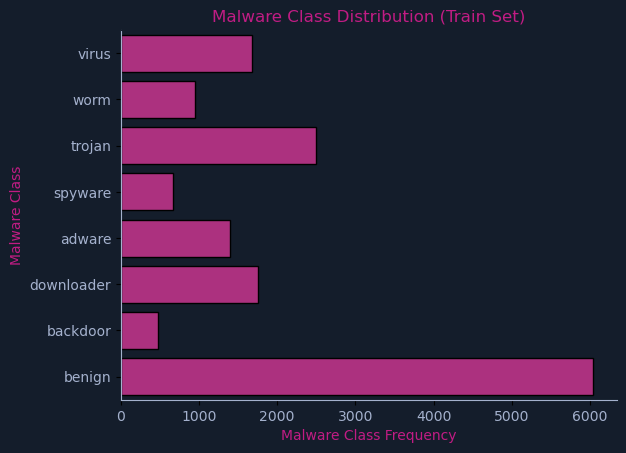

In [4]:
# choose split to visualize
split = "train"

classes = list(dist[split].keys())
frequencies = list(dist[split].values())
pink = "#C11C84"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

plt.figure(facecolor=node_black)

sns.barplot(
    y=classes,
    x=frequencies,
    orient="h",
    color=pink,
    edgecolor="black"
)

plt.title("Malware Class Distribution (Train Set)", color=pink)
plt.xlabel("Malware Class Frequency", color=pink)
plt.ylabel("Malware Class", color=pink)

plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)

ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines["bottom"].set_color(hacker_grey)
ax.spines["left"].set_color(hacker_grey)
ax.spines["top"].set_color(node_black)
ax.spines["right"].set_color(node_black)

plt.show()


In [5]:
from PIL import Image
import os

sizes = []
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATA_BASE, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        for fname in os.listdir(cls_path):
            img = Image.open(os.path.join(cls_path, fname))
            sizes.append(img.size)  # (width, height)

# Basic stats
widths, heights = zip(*sizes)
print("Min size:", min(widths), min(heights))
print("Max size:", max(widths), max(heights))
print("Average size:", sum(widths)//len(widths), sum(heights)//len(heights))

#Min size: 299 299
#Max size: 299 299
#Average size: 299 299
#already done.

Min size: 299 299
Max size: 299 299
Average size: 299 299


In [6]:

from torchvision import transforms

# Define preprocessing transforms
transform = transforms.Compose([
	transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.03593449,0.0138905,0.05819073], std=[0.15817634,0.07281315,0.18924118])
])


In [7]:
from torchvision.datasets import ImageFolder
import os

BASE_PATH = "/home/beylessen/Desktop/PFA2/Sorted"

# Training dataset
train_dataset = ImageFolder(
    root=os.path.join(BASE_PATH, "train"),
    transform=transform
)

# Validation dataset
val_dataset = ImageFolder(
    root=os.path.join(BASE_PATH, "val"),
    transform=transform
)

# Test dataset
test_dataset = ImageFolder(
    root=os.path.join(BASE_PATH, "test"),
    transform=transform
)


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30749506..13.543014].


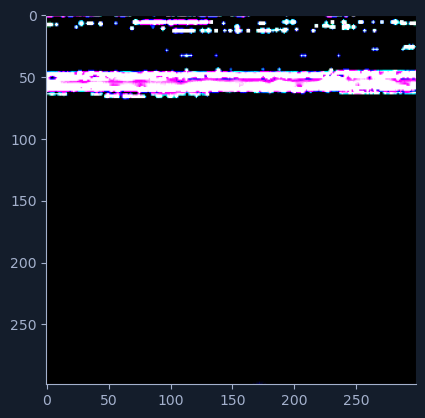

In [9]:
import matplotlib.pyplot as plt

pink = "#C11C84"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

# image
sample = next(iter(train_loader))[0][0]

# plot
plt.figure(facecolor=node_black)
plt.imshow(sample.permute(1,2,0))
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)
ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines['bottom'].set_color(hacker_grey)
ax.spines['top'].set_color(node_black)
ax.spines['right'].set_color(node_black)
ax.spines['left'].set_color(hacker_grey)
ax.tick_params(axis='x', colors=hacker_grey)
ax.tick_params(axis='y', colors=hacker_grey)
plt.show()


In [10]:
import torch.nn as nn
import torchvision.models as models

HIDDEN_LAYER_SIZE = 1000

class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MalwareClassifier, self).__init__()
        # Load pretrained ResNet50
        self.resnet = models.resnet50(weights='DEFAULT')
        
        # Freeze ResNet parameters
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        # Replace the last fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes)
        )

    def forward(self, x):
        return self.resnet(x)


In [11]:
model = MalwareClassifier(8)

In [12]:
import torch
import time

def train(model, train_loader, n_epochs, device, class_weights=None, verbose=False):
    model.to(device)
    model.train()

    # Loss function (optionally weighted for class imbalance)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights).to(device)

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    training_data = {"accuracy": [], "loss": []}

    for epoch in range(n_epochs):
        running_loss = 0.0
        n_total = 0
        n_correct = 0
        start_time = time.time()

        for inputs, labels in train_loader:
            # Move data to CPU/GPU
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)              # (batch_size, 8)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            # Accuracy
            _, predicted = torch.max(outputs, 1)
            n_total += labels.size(0)
            n_correct += (predicted == labels).sum().item()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100.0 * n_correct / n_total
        epoch_duration = time.time() - start_time

        training_data["accuracy"].append(epoch_accuracy)
        training_data["loss"].append(epoch_loss)

        if verbose:
            print(
                f"[Epoch {epoch+1}/{n_epochs}] "
                f"Accuracy: {epoch_accuracy:.2f}% | "
                f"Loss: {epoch_loss:.4f} | "
                f"Time: {epoch_duration:.1f}s"
            )

    return training_data


In [13]:
def save_model(model, path):
	model_scripted = torch.jit.script(model)
	model_scripted.save(path)


In [14]:
def predict(model, test_data):
    model.eval()

    with torch.no_grad():
        output = model(test_data)
        _, predicted = torch.max(output.data, 1)

    return predicted

In [15]:
def validate(model, val_loader, device):
    model.eval()

    n_total = 0
    n_correct = 0
    running_loss = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            n_total += labels.size(0)
            n_correct += (predicted == labels).sum().item()
            running_loss += loss.item()

    val_loss = running_loss / len(val_loader)
    val_accuracy = 100.0 * n_correct / n_total

    return val_loss, val_accuracy


In [16]:
def compute_accuracy(n_correct, n_total):
    return round(100 * n_correct / n_total, 2)

def evaluate(model, test_loader, device):
    model.to(device)
    model.eval()

    n_correct = 0
    n_total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            predicted = predict(model, data)
            n_total += target.size(0)
            n_correct += (predicted == target).sum().item()

    return compute_accuracy(n_correct, n_total)


In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

def load_datasets(data_path, train_bs, val_bs, test_bs):
    # ImageNet normalization (required for ResNet)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    ])

    train_dir = os.path.join(data_path, "train")
    val_dir   = os.path.join(data_path, "val")
    test_dir  = os.path.join(data_path, "test")

    train_dataset = datasets.ImageFolder(train_dir, transform=transform)
    val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
    test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

    train_loader = DataLoader(
        train_dataset, batch_size=train_bs, shuffle=True, num_workers=4
    )

    val_loader = DataLoader(
        val_dataset, batch_size=val_bs, shuffle=False, num_workers=4
    )

    test_loader = DataLoader(
        test_dataset, batch_size=test_bs, shuffle=False, num_workers=4
    )

    n_classes = len(train_dataset.classes)
    return train_loader, val_loader, test_loader, n_classes


In [18]:
import matplotlib.pyplot as plt

def plot(data, title, label, xlabel, ylabel):
    pink = "#C11C84"
    node_black = "#141D2B"
    hacker_grey = "#A4B1CD"

    # plot
    plt.figure(figsize=(10, 6), facecolor=node_black)
    plt.plot(range(1, len(data)+1), data, label=label, color=pink)
    plt.title(title, color=pink)
    plt.xlabel(xlabel, color=pink)
    plt.ylabel(ylabel, color=pink)
    plt.xticks(color=hacker_grey)
    plt.yticks(color=hacker_grey)
    ax = plt.gca()
    ax.set_facecolor(node_black)
    ax.spines['bottom'].set_color(hacker_grey)
    ax.spines['top'].set_color(node_black)
    ax.spines['right'].set_color(node_black)
    ax.spines['left'].set_color(hacker_grey)

    legend = plt.legend(facecolor=node_black, edgecolor=hacker_grey, fontsize=10)
    plt.setp(legend.get_texts(), color=pink)
    
    plt.show()

def plot_training_accuracy(training_data):
    plot(training_data['accuracy'], "Training Accuracy", "Accuracy", "Epoch", "Accuracy (%)")

def plot_training_loss(training_data):
    plot(training_data['loss'], "Training Loss", "Loss", "Epoch", "Loss")


[i] Starting Training...
[Epoch 1/10] Accuracy: 83.83% | Loss: 0.5762 | Time: 1499.6s
[Epoch 2/10] Accuracy: 94.05% | Loss: 0.2363 | Time: 1595.0s
[Epoch 3/10] Accuracy: 95.23% | Loss: 0.1811 | Time: 1590.5s
[Epoch 4/10] Accuracy: 95.78% | Loss: 0.1541 | Time: 1501.1s
[Epoch 5/10] Accuracy: 96.53% | Loss: 0.1301 | Time: 3621.5s
[Epoch 6/10] Accuracy: 96.92% | Loss: 0.1180 | Time: 1500.1s
[Epoch 7/10] Accuracy: 97.02% | Loss: 0.1085 | Time: 1514.3s
[Epoch 8/10] Accuracy: 97.16% | Loss: 0.1012 | Time: 1515.5s
[Epoch 9/10] Accuracy: 97.36% | Loss: 0.0911 | Time: 1544.9s
[Epoch 10/10] Accuracy: 97.61% | Loss: 0.0843 | Time: 1569.8s
[i] Validation Accuracy: 97.01%
[i] Test Accuracy: 96.92%


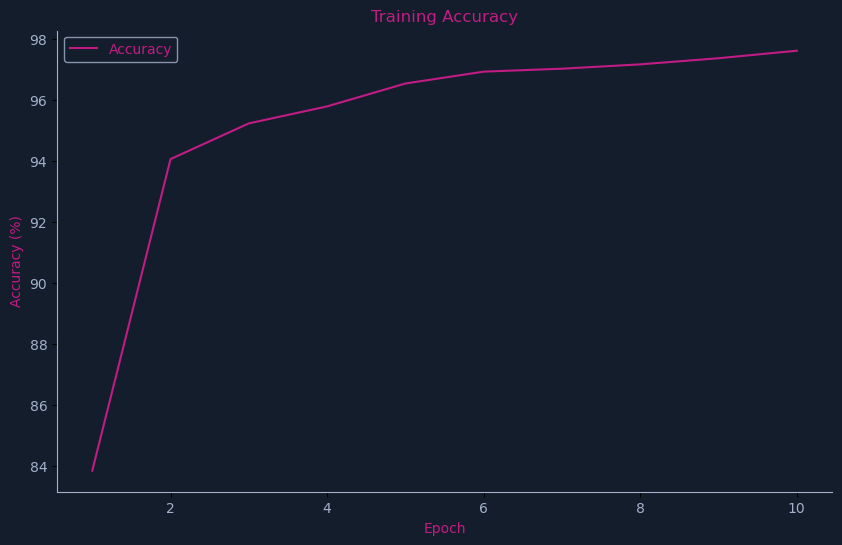

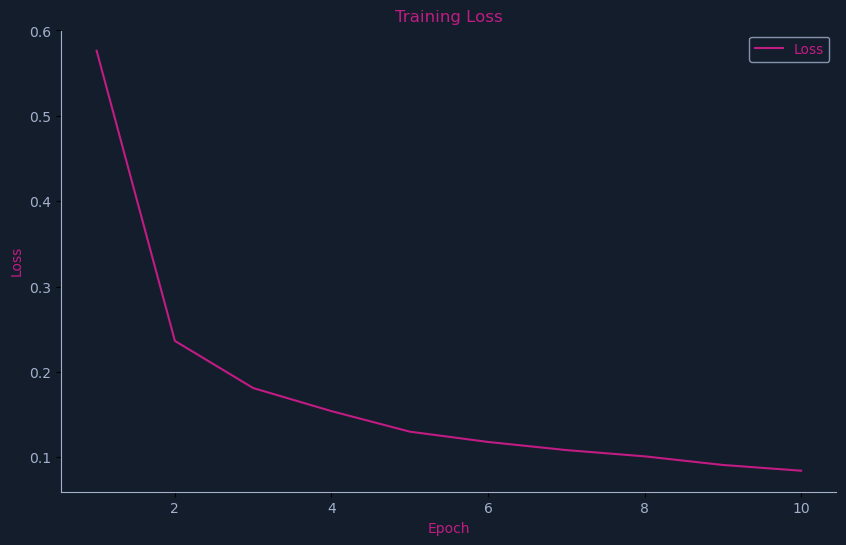

In [19]:
import torch

# =========================
# Data parameters
# =========================
DATA_PATH = "/home/beylessen/Desktop/PFA2/Sorted"

# =========================
# Training parameters
# =========================
N_EPOCHS = 10
TRAIN_BATCH_SIZE = 32
VAL_BATCH_SIZE = 32
TEST_BATCH_SIZE = 32

# =========================
# Model parameters
# =========================
MODEL_FILE = "malware_classifier.pth"

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Load datasets
# =========================
train_loader, val_loader, test_loader, n_classes = load_datasets(
    DATA_PATH,
    TRAIN_BATCH_SIZE,
    VAL_BATCH_SIZE,
    TEST_BATCH_SIZE
)

# =========================
# Initialize model
# =========================
model = MalwareClassifier(n_classes)

# =========================
# Train model
# =========================
print("[i] Starting Training...")
training_information = train(
    model,
    train_loader,
    N_EPOCHS,
    device=device,
    verbose=True
)

# =========================
# Validate model
# =========================
val_loss, val_accuracy = validate(model, val_loader, device)
print(f"[i] Validation Accuracy: {val_accuracy:.2f}%")

# =========================
# Save model
# =========================
save_model(model, MODEL_FILE)

# =========================
# Test model (final evaluation)
# =========================
test_accuracy = evaluate(model, test_loader, device)
print(f"[i] Test Accuracy: {test_accuracy:.2f}%")

# =========================
# Plot training details
# =========================
plot_training_accuracy(training_information)
plot_training_loss(training_information)
